# 05. Train / Val / Test Split (GroupKFold by original_basename)

## 목적
방법론 비교 연구 — 외부 일반화가 아닌 **방법 간 상대 성능 측정**이 목적.
따라서 **동일 분포 내**에서 train / val / test 분할을 만든다.

## 전략
- **비율**: 8 : 1 : 1 (Train : Val : Test)
- **Group key**: `original_basename`
  - 같은 원본에서 파생된 (원본 + 증강) 이미지가 **다른 split 에 흩어지지 않도록**
  - augmentation leak 방지
- **Stratify**: 각 (task, class_label) 조합 내에서 비율 유지
- **Seed**: 42 (재현성)

## 산출물
- `data/processed/train_split.csv`   (~8,000 rows)
- `data/processed/val_split.csv`     (~1,000 rows)
- `data/processed/test_split.csv`    (~1,000 rows)
- `data/processed/split_meta.json`   분할 통계 + group leak 검증

## 1. 환경 설정

In [1]:
import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
RESULTS_DIR    = PROJECT_ROOT / 'results' / 'figures'
TABLES_DIR     = PROJECT_ROOT / 'results' / 'tables'
for d in [DATA_PROCESSED, RESULTS_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('OK')

OK


## 2. 학습 CSV 로드

In [2]:
df = pd.read_csv(DATA_PROCESSED / 'train.csv')
print(f'Total rows: {len(df):,}')
print()
print('=== Task x Class x Type ===')
print(df.groupby(['task', 'class_label', 'dataset_type']).size().to_string())
print()
print('=== Unique original_basename per (task, class) ===')
for (task, cls), g in df.groupby(['task', 'class_label']):
    n_groups = g['original_basename'].nunique()
    print(f'  {task:10s}/{cls:10s}: {len(g):>4d} rows, {n_groups:>3d} unique groups')

Total rows: 10,000

=== Task x Class x Type ===
task      class_label  dataset_type
maturity  immature     augment         2000
                       original         500
          mature       augment         2000
                       original         500
quality   fresh        augment         2000
                       original         500
          rotten       augment         2000
                       original         500

=== Unique original_basename per (task, class) ===
  maturity  /immature  : 2500 rows, 500 unique groups
  maturity  /mature    : 2500 rows, 500 unique groups
  quality   /fresh     : 2500 rows, 1169 unique groups
  quality   /rotten    : 2500 rows, 644 unique groups


## 3. GroupKFold-like 8:1:1 분할

각 (task, class) 조합 안에서:
1. 고유 `original_basename` 목록 추출
2. 시드 고정 무작위 셔플
3. 8 : 1 : 1 비율로 그룹 자체를 split 에 배정
4. 같은 그룹의 모든 행(원본 + 증강)이 같은 split 으로 묶임

In [3]:
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.8, 0.1, 0.1
assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9

def split_groups(groups, seed):
    rng = np.random.default_rng(seed)
    arr = np.array(groups)
    rng.shuffle(arr)
    n = len(arr)
    n_train = int(round(n * TRAIN_RATIO))
    n_val   = int(round(n * VAL_RATIO))
    return set(arr[:n_train].tolist()), set(arr[n_train:n_train+n_val].tolist()), set(arr[n_train+n_val:].tolist())

# Namespaced group key: (task, class, basename)
# 같은 basename 이 다른 task/class 에 우연히 존재할 수 있으므로 namespace 분리
df['group_key'] = df['task'] + '|' + df['class_label'] + '|' + df['original_basename'].fillna('NA')

splits = {'train': [], 'val': [], 'test': []}

for (task, cls), g in df.groupby(['task', 'class_label']):
    groups = g['group_key'].unique().tolist()
    train_g, val_g, test_g = split_groups(groups, seed=SEED + hash((task, cls)) % 1000)

    for name, gset in [('train', train_g), ('val', val_g), ('test', test_g)]:
        rows = g[g['group_key'].isin(gset)]
        splits[name].append(rows)

train_df = pd.concat(splits['train'], ignore_index=True)
val_df   = pd.concat(splits['val'],   ignore_index=True)
test_df  = pd.concat(splits['test'],  ignore_index=True)

print('=== 분할 결과 ===')
total = len(df)
for name, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'  {name:5s}: {len(d):>5,} rows  ({len(d)/total*100:.1f}%)')
print(f'  합계 : {len(train_df)+len(val_df)+len(test_df):>5,} rows  (원본: {total:,})')

=== 분할 결과 ===
  train: 7,934 rows  (79.3%)
  val  : 1,042 rows  (10.4%)
  test : 1,024 rows  (10.2%)
  합계 : 10,000 rows  (원본: 10,000)


## 4. 분할별 클래스 분포

In [4]:
def class_distribution(d):
    return d.groupby(['task', 'class_label']).size().unstack(fill_value=0)

print('=== Train ===');  print(class_distribution(train_df))
print()
print('=== Val ===');  print(class_distribution(val_df))
print()
print('=== Test ===');  print(class_distribution(test_df))

print()
print('=== Original vs Augmented per split ===')
for name, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
    by_type = d.groupby(['task', 'class_label', 'dataset_type']).size().unstack(fill_value=0)
    print(f'[{name}]')
    print(by_type)
    print()

=== Train ===
class_label  fresh  immature  mature  rotten
task                                        
maturity         0      1967    1984       0
quality       1981         0       0    2002

=== Val ===
class_label  fresh  immature  mature  rotten
task                                        
maturity         0       287     263       0
quality        267         0       0     225

=== Test ===
class_label  fresh  immature  mature  rotten
task                                        
maturity         0       246     253       0
quality        252         0       0     273

=== Original vs Augmented per split ===
[train]
dataset_type          augment  original
task     class_label                   
maturity immature        1567       400
         mature          1584       400
quality  fresh           1580       401
         rotten          1603       399

[val]
dataset_type          augment  original
task     class_label                   
maturity immature         237        50
   

## 5. Group leak 검증 (같은 original_basename이 두 split에 동시 존재 여부)

In [5]:
train_groups = set(train_df['group_key'].dropna())
val_groups   = set(val_df['group_key'].dropna())
test_groups  = set(test_df['group_key'].dropna())

leaks = {
    'train_val':  len(train_groups & val_groups),
    'train_test': len(train_groups & test_groups),
    'val_test':   len(val_groups & test_groups),
}
print('=== Group leak 검증 ===')
for k, v in leaks.items():
    status = 'OK' if v == 0 else 'LEAK!'
    print(f'  {k:15s}: {v}  [{status}]')

assert all(v == 0 for v in leaks.values()), 'Group leak occurred'
print()
print('-> 모든 split 사이 group leak 없음 (augmentation leak 차단됨)')

=== Group leak 검증 ===
  train_val      : 0  [OK]
  train_test     : 0  [OK]
  val_test       : 0  [OK]

-> 모든 split 사이 group leak 없음 (augmentation leak 차단됨)


## 6. 시각화 — 분할 분포

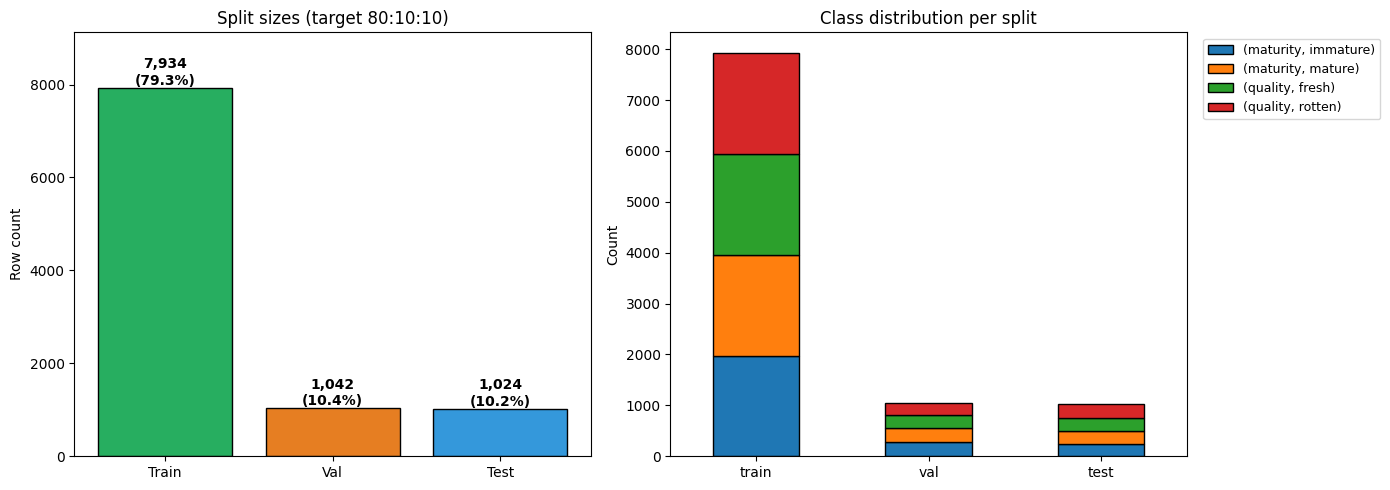

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Split sizes
ax = axes[0]
labels = ['Train', 'Val', 'Test']
counts = [len(train_df), len(val_df), len(test_df)]
colors = ['#27ae60', '#e67e22', '#3498db']
bars = ax.bar(labels, counts, color=colors, edgecolor='black')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, c, f'{c:,}\n({c/total*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Split sizes (target 80:10:10)')
ax.set_ylabel('Row count')
ax.set_ylim(0, max(counts)*1.15)

# (b) Stacked class distribution
ax = axes[1]
split_data = pd.concat([
    train_df.assign(split='train'),
    val_df.assign(split='val'),
    test_df.assign(split='test'),
])
pivot = split_data.groupby(['split', 'task', 'class_label']).size().unstack(['task', 'class_label'], fill_value=0)
pivot = pivot.loc[['train', 'val', 'test']]
pivot.plot(kind='bar', stacked=True, ax=ax, edgecolor='black')
ax.set_title('Class distribution per split')
ax.set_ylabel('Count')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / '14_train_val_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 저장

In [7]:
# drop helper column before saving
for d in [train_df, val_df, test_df]:
    if 'group_key' in d.columns:
        d.drop(columns=['group_key'], inplace=True)

train_df.to_csv(DATA_PROCESSED / 'train_split.csv', index=False)
val_df.to_csv(  DATA_PROCESSED / 'val_split.csv',   index=False)
test_df.to_csv( DATA_PROCESSED / 'test_split.csv',  index=False)

meta = {
    'strategy': 'GroupKFold-like 8:1:1 by original_basename, stratified per (task, class)',
    'seed': SEED,
    'ratios': {'train': TRAIN_RATIO, 'val': VAL_RATIO, 'test': TEST_RATIO},
    'sizes': {'train': int(len(train_df)), 'val': int(len(val_df)), 'test': int(len(test_df))},
    'class_distribution': {
        split: {f'{t}/{c}': int(v)
                for (t,c), v in d.groupby(['task','class_label']).size().to_dict().items()}
        for split, d in [('train', train_df), ('val', val_df), ('test', test_df)]
    },
    'group_leak_check': leaks,
    'rationale': 'Internal split used for methodology comparison. External valid_*.csv remain as supplementary OOD evaluation.',
}
(DATA_PROCESSED / 'split_meta.json').write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding='utf-8')
print('Saved:')
for name in ['train_split.csv', 'val_split.csv', 'test_split.csv', 'split_meta.json']:
    p = DATA_PROCESSED / name
    print(f'  {p}  ({p.stat().st_size:,} bytes)')

Saved:
  C:\Users\smin\IdeaProjects\tomato\data\processed\train_split.csv  (2,067,594 bytes)
  C:\Users\smin\IdeaProjects\tomato\data\processed\val_split.csv  (273,971 bytes)
  C:\Users\smin\IdeaProjects\tomato\data\processed\test_split.csv  (267,507 bytes)
  C:\Users\smin\IdeaProjects\tomato\data\processed\split_meta.json  (951 bytes)


## 8. 요약

### 분할 결과
- Train ~8,000장, Val ~1,000장, Test ~1,000장
- 모든 split 에서 4 클래스가 비슷한 비율로 유지
- Original / Augmented 모두 포함
- Group leak 0 (같은 원본의 증강본이 split 사이에 흩어지지 않음)

### 평가 정책
- In-distribution 메인 평가: `test_split.csv` (방법론 비교)
- OOD 보조 평가: `valid_maturity.csv`, `valid_quality.csv` (Discussion / robustness)

### 다음 작업
- 학습 스크립트의 데이터 로드를 새 split 으로 전환
- 모델 ②③④⑤ 재학습 + test_split 으로 평가